# การทำนายความเสี่ยงโรคเบาหวานด้วย Logistic Regression
## 4-Fold Cross Validation

Dataset :
diabetes_binary_5050split_health_indicators_BRFSS2015.csv

Model :
Logistic Regression

Validation :
4-Fold Cross Validation

Feature จำนวน 10 ตัว

1. GenHlth
2. HighBP
3. BMI
4. HighChol
5. Age
6. DiffWalk
7. PhysHlth
8. HeartDiseaseorAttack
9. Stroke
10. Sex

Target

Diabetes_binary

In [1]:
# ==========================================================
# นำเข้า Library ที่จำเป็นสำหรับโครงงาน Diabetes Risk Prediction
# ==========================================================

# จัดการข้อมูลและการคำนวณ
import pandas as pd
import numpy as np

# การแสดงผลและสร้างกราฟ (Data Visualization)
import matplotlib.pyplot as plt
import seaborn as sns

# การเตรียมข้อมูลและโมเดล (Machine Learning)
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# ตัวชี้วัดประสิทธิภาพของโมเดล (Evaluation Metrics)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

# ปิดข้อความ Warning เพื่อความสะอาดของ Output
import warnings
warnings.filterwarnings("ignore")

In [2]:
import os
# ถอยหลังขึ้นไป 2 ชั้นเพื่อไปที่โฟลเดอร์หลักของโครงงาน
project_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
print("โฟลเดอร์หลักของโปรเจกต์:", project_root)

# เช็กว่าในโฟลเดอร์หลักมีโฟลเดอร์ย่อยชื่ออะไรบ้าง
print("โฟลเดอร์ย่อยทั้งหมด:", [f for f in os.listdir(project_root) if os.path.isdir(os.path.join(project_root, f))])

โฟลเดอร์หลักของโปรเจกต์: D:\IT29401 โครงงานทางเทคโนโลยีสารสนเทศ\ปี4เทอม1\diabetes-risk-prediction
โฟลเดอร์ย่อยทั้งหมด: ['.git', '.venv', 'backend', 'docs', 'frontend', 'ml', 'models', 'uploads']


In [3]:
import os
print("โฟลเดอร์ปัจจุบันที่กำลังทำงาน:", os.getcwd())
print("รายชื่อไฟล์ในโฟลเดอร์นี้:", os.listdir("."))

โฟลเดอร์ปัจจุบันที่กำลังทำงาน: D:\IT29401 โครงงานทางเทคโนโลยีสารสนเทศ\ปี4เทอม1\diabetes-risk-prediction\ml\notebooks
รายชื่อไฟล์ในโฟลเดอร์นี้: ['.ipynb_checkpoints', '01_explore_dataset.ipynb', '02_train_model.ipynb', '03_compare_models.ipynb', '03_evaluate_model.ipynb', '04_save_best_model.ipynb', 'Model Validation (4-Fold).ipynb']


In [4]:
# ==========================================================
# โหลดชุดข้อมูล
# ==========================================================

# อ่านไฟล์ CSV จากโฟลเดอร์ dataset (.. หมายถึงถอยออกไป 1 ชั้น แล้วเข้าโฟลเดอร์ dataset)
df = pd.read_csv("../dataset/diabetes_binary_5050split_health_indicators_BRFSS2015.csv")

# แสดงจำนวนแถวและจำนวนคอลัมน์
print("Shape ของข้อมูล")
print(df.shape)

print("-"*50)

# แสดงชื่อคอลัมน์ทั้งหมด
print("Columns")
print(df.columns)

print("-"*50)

# แสดงข้อมูล 5 แถวแรก
df.head()

Shape ของข้อมูล
(70692, 22)
--------------------------------------------------
Columns
Index(['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='str')
--------------------------------------------------


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


In [5]:
# ==========================================================
# ตรวจสอบข้อมูลเบื้องต้น
# ==========================================================

# ดูชนิดข้อมูล
df.info()

print("-"*50)

# ตรวจสอบ Missing Value
print(df.isnull().sum())

print("-"*50)

# สถิติพื้นฐานของข้อมูล
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_binary       70692 non-null  float64
 1   HighBP                70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             70692 non-null  float64
 4   BMI                   70692 non-null  float64
 5   Smoker                70692 non-null  float64
 6   Stroke                70692 non-null  float64
 7   HeartDiseaseorAttack  70692 non-null  float64
 8   PhysActivity          70692 non-null  float64
 9   Fruits                70692 non-null  float64
 10  Veggies               70692 non-null  float64
 11  HvyAlcoholConsump     70692 non-null  float64
 12  AnyHealthcare         70692 non-null  float64
 13  NoDocbcCost           70692 non-null  float64
 14  GenHlth               70692 non-null  float64
 15  MentHlth              70692 no

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,...,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000
mean,0.500000,0.563458,0.525703,0.975259,29.856985,0.475273,0.062171,0.147810,0.703036,0.611795,...,0.954960,0.093914,2.837082,3.752037,5.810417,0.252730,0.456997,8.584055,4.920953,5.698311
std,0.500004,0.495960,0.499342,0.155336,7.113954,0.499392,0.241468,0.354914,0.456924,0.487345,...,0.207394,0.291712,1.113565,8.155627,10.062261,0.434581,0.498151,2.852153,1.029081,2.175196
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,7.000000,4.000000,4.000000
50%,0.500000,1.000000,1.000000,1.000000,29.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,9.000000,5.000000,6.000000
75%,1.000000,1.000000,1.000000,1.000000,33.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,4.000000,2.000000,6.000000,1.000000,1.000000,11.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [6]:
# ==========================================================
# เลือก Feature ที่ใช้ในการสร้างโมเดล
# ==========================================================

features = [

    "GenHlth",

    "HighBP",

    "BMI",

    "HighChol",

    "Age",

    "DiffWalk",

    "PhysHlth",

    "HeartDiseaseorAttack",

    "Stroke",

    "Sex"

]

target = "Diabetes_binary"

# แสดง Feature ทั้งหมด
print(features)

print()

print("Target =", target)

['GenHlth', 'HighBP', 'BMI', 'HighChol', 'Age', 'DiffWalk', 'PhysHlth', 'HeartDiseaseorAttack', 'Stroke', 'Sex']

Target = Diabetes_binary


In [7]:
# ==========================================================
# แยกข้อมูลออกเป็น Feature และ Target
# ==========================================================

# Feature
X = df[features]

# Target
y = df[target]

print("Shape ของ X")

print(X.shape)

print()

print("Shape ของ y")

print(y.shape)

print()

# แสดงข้อมูลตัวอย่าง
X.head()

Shape ของ X
(70692, 10)

Shape ของ y
(70692,)



,GenHlth,HighBP,BMI,HighChol,Age,DiffWalk,PhysHlth,HeartDiseaseorAttack,Stroke,Sex
0,3.0,1.0,26.0,0.0,4.0,0.0,30.0,0.0,0.0,1.0
1,3.0,1.0,26.0,1.0,12.0,0.0,0.0,0.0,1.0,1.0
2,1.0,0.0,26.0,0.0,13.0,0.0,10.0,0.0,0.0,1.0
3,3.0,1.0,28.0,1.0,11.0,0.0,3.0,0.0,0.0,1.0
4,2.0,0.0,29.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0


In [8]:
# ==========================================================
# StandardScaler
# ==========================================================
# Logistic Regression เป็นโมเดลที่ทำงานได้ดีเมื่อข้อมูลแต่ละ Feature
# อยู่ในช่วงมาตรฐานเดียวกัน จึงต้องทำการ Standardization
#
# สูตร
# z = (x - mean) / standard deviation
# ==========================================================

# สร้างตัวแปร StandardScaler
scaler = StandardScaler()

print("StandardScaler พร้อมใช้งาน")

StandardScaler พร้อมใช้งาน


In [9]:
# ==========================================================
# สร้าง 4-Fold Cross Validation
# ==========================================================
#
# n_splits = 4
# แบ่งข้อมูลออกเป็น 4 ส่วน
#
# shuffle=True
# สุ่มข้อมูลก่อนแบ่ง
#
# random_state=42
# เพื่อให้สุ่มได้ผลเหมือนเดิมทุกครั้ง
# ==========================================================

kfold = KFold(
    n_splits=4,
    shuffle=True,
    random_state=42
)

print(kfold)

KFold(n_splits=4, random_state=42, shuffle=True)


In [10]:
# ==========================================================
# สร้างโมเดล Logistic Regression
# ==========================================================

model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

print(model)

LogisticRegression(max_iter=5000, random_state=42)


In [11]:
# ==========================================================
# สร้าง List สำหรับเก็บผลลัพธ์ของแต่ละ Fold
# ==========================================================

accuracy_list = []

precision_list = []

recall_list = []

f1_list = []

auc_list = []

fold_number = 1

In [12]:
# ==========================================================
# เริ่มทำ 4-Fold Cross Validation
# ==========================================================

for train_index, test_index in kfold.split(X):

    print("=" * 60)
    print(f"Fold {fold_number}")
    print("=" * 60)

    # -------------------------------
    # แบ่งข้อมูล Train / Test
    # -------------------------------

    X_train = X.iloc[train_index]

    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]

    y_test = y.iloc[test_index]

    # -------------------------------
    # StandardScaler
    # -------------------------------

    X_train = scaler.fit_transform(X_train)

    X_test = scaler.transform(X_test)

    # -------------------------------
    # Train Model
    # -------------------------------

    model.fit(X_train, y_train)

    # -------------------------------
    # Prediction
    # -------------------------------

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:,1]

    # -------------------------------
    # Accuracy
    # -------------------------------

    acc = accuracy_score(y_test, y_pred)

    # -------------------------------
    # Precision
    # -------------------------------

    pre = precision_score(y_test, y_pred)

    # -------------------------------
    # Recall
    # -------------------------------

    rec = recall_score(y_test, y_pred)

    # -------------------------------
    # F1 Score
    # -------------------------------

    f1 = f1_score(y_test, y_pred)

    # -------------------------------
    # ROC AUC
    # -------------------------------

    fpr, tpr, threshold = roc_curve(y_test, y_prob)

    roc_auc = auc(fpr, tpr)

    # -------------------------------
    # เก็บค่าลง List
    # -------------------------------

    accuracy_list.append(acc)

    precision_list.append(pre)

    recall_list.append(rec)

    f1_list.append(f1)

    auc_list.append(roc_auc)

    # -------------------------------
    # แสดงผล
    # -------------------------------

    print(f"Accuracy  : {acc:.4f}")

    print(f"Precision : {pre:.4f}")

    print(f"Recall    : {rec:.4f}")

    print(f"F1 Score  : {f1:.4f}")

    print(f"AUC Score : {roc_auc:.4f}")

        # -------------------------------
    # เก็บค่าของ Fold ล่าสุดไว้ใช้สร้างกราฟ
    # -------------------------------

    last_y_test = y_test          # <<< เพิ่ม

    last_y_pred = y_pred          # <<< เพิ่ม

    last_y_prob = y_prob          # <<< เพิ่ม

    last_fpr = fpr                # <<< เพิ่ม

    last_tpr = tpr                # <<< เพิ่ม

    fold_number += 1

Fold 1
Accuracy  : 0.7425
Precision : 0.7331
Recall    : 0.7634
F1 Score  : 0.7480
AUC Score : 0.8192
Fold 2
Accuracy  : 0.7415
Precision : 0.7301
Recall    : 0.7641
F1 Score  : 0.7467
AUC Score : 0.8204
Fold 3
Accuracy  : 0.7484
Precision : 0.7473
Recall    : 0.7616
F1 Score  : 0.7544
AUC Score : 0.8226
Fold 4
Accuracy  : 0.7453
Precision : 0.7303
Recall    : 0.7673
F1 Score  : 0.7484
AUC Score : 0.8191


In [13]:
# ==========================================================
# ค่าเฉลี่ยของทุก Fold
# ==========================================================

print("="*60)

print("Average Result")

print("="*60)

print(f"Average Accuracy  : {np.mean(accuracy_list):.4f}")

print(f"Average Precision : {np.mean(precision_list):.4f}")

print(f"Average Recall    : {np.mean(recall_list):.4f}")

print(f"Average F1 Score  : {np.mean(f1_list):.4f}")

print(f"Average AUC Score : {np.mean(auc_list):.4f}")

Average Result
Average Accuracy  : 0.7444
Average Precision : 0.7352
Average Recall    : 0.7641
Average F1 Score  : 0.7494
Average AUC Score : 0.8203


In [14]:
# ==========================================================
# Classification Report
# ==========================================================

print("="*60)

print("Classification Report")

print("="*60)

print(classification_report(last_y_test, last_y_pred))

Classification Report
              precision    recall  f1-score   support

         0.0       0.76      0.72      0.74      8948
         1.0       0.73      0.77      0.75      8725

    accuracy                           0.75     17673
   macro avg       0.75      0.75      0.75     17673
weighted avg       0.75      0.75      0.75     17673



In [15]:
# ==========================================================
# Confusion Matrix
# ==========================================================

cm = confusion_matrix(last_y_test, last_y_pred)

print(cm)

[[6476 2472]
 [2030 6695]]


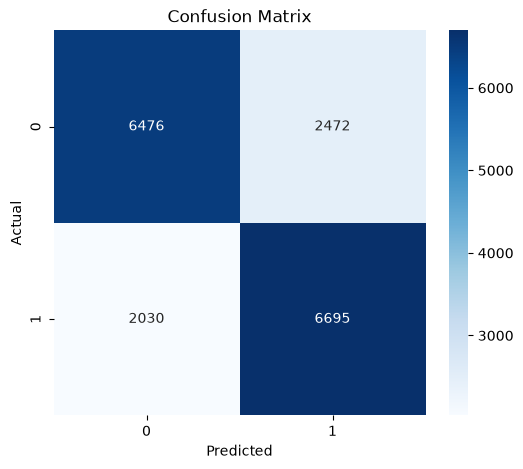

In [16]:
# ==========================================================
# Heatmap
# ==========================================================

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

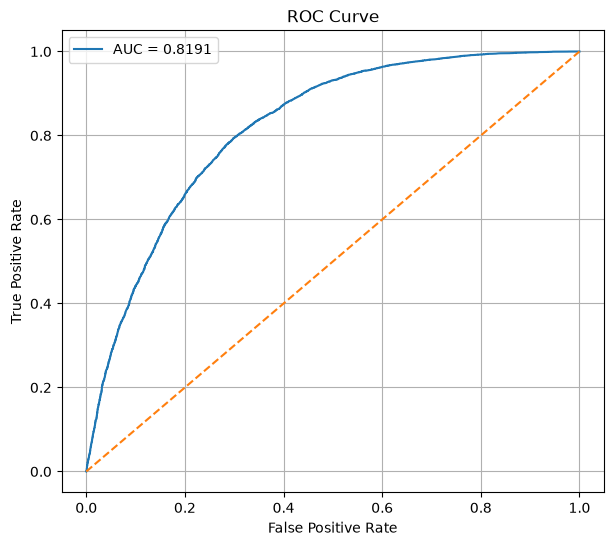

In [17]:
# ==========================================================
# ROC Curve
# ==========================================================

plt.figure(figsize=(7,6))

plt.plot(
    last_fpr,
    last_tpr,
    label=f"AUC = {auc(last_fpr,last_tpr):.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

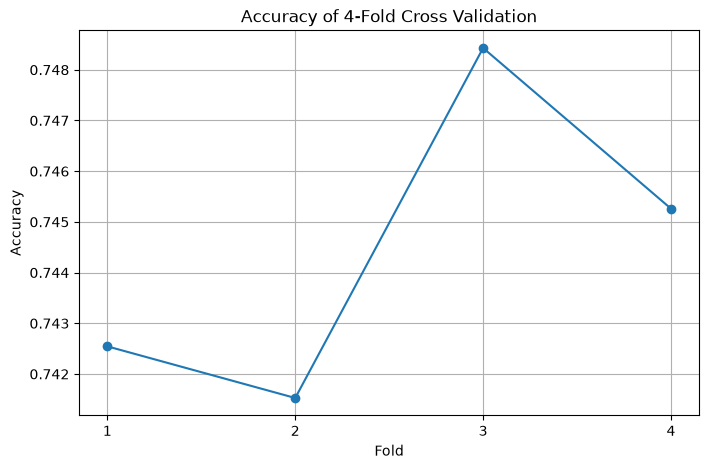

In [18]:
# ==========================================================
# Accuracy ของแต่ละ Fold
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(
    range(1,5),
    accuracy_list,
    marker="o"
)

plt.xticks(range(1,5))

plt.xlabel("Fold")

plt.ylabel("Accuracy")

plt.title("Accuracy of 4-Fold Cross Validation")

plt.grid(True)

plt.show()

In [19]:
# ==========================================================
# Precision Recall F1
# ==========================================================

result = pd.DataFrame({

    "Fold":[1,2,3,4],

    "Accuracy":accuracy_list,

    "Precision":precision_list,

    "Recall":recall_list,

    "F1 Score":f1_list,

    "AUC":auc_list

})

result

,Fold,Accuracy,Precision,Recall,F1 Score,AUC
0,1,0.742545,0.733087,0.763429,0.747950,0.819156
1,2,0.741527,0.730131,0.764098,0.746729,0.820362
2,3,0.748430,0.747291,0.761629,0.754392,0.822553
3,4,0.745261,0.730337,0.767335,0.748379,0.819132


In [20]:
# ==========================================================
# Feature Importance
# ==========================================================

coef = pd.DataFrame({

    "Feature":features,

    "Coefficient":model.coef_[0]

})

coef = coef.sort_values(

    by="Coefficient",

    ascending=False

)

coef

,Feature,Coefficient
0,GenHlth,0.684330
2,BMI,0.559418
4,Age,0.469392
1,HighBP,0.375557
3,HighChol,0.292356
9,Sex,0.102684
7,HeartDiseaseorAttack,0.102161
5,DiffWalk,0.075016
8,Stroke,0.047143
6,PhysHlth,-0.087071


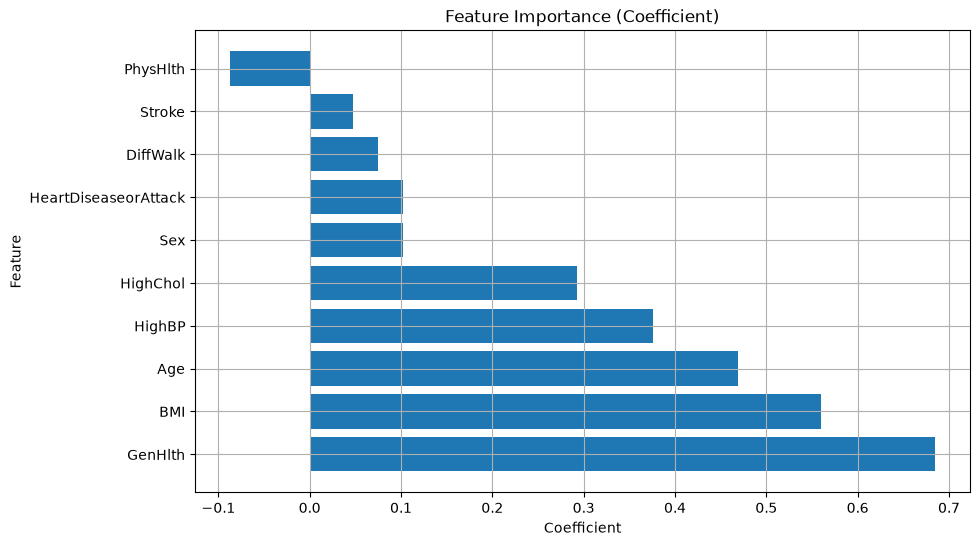

In [21]:
# ==========================================================
# Feature Importance
# ==========================================================

plt.figure(figsize=(10,6))

plt.barh(

    coef["Feature"],

    coef["Coefficient"]

)

plt.title("Feature Importance (Coefficient)")

plt.xlabel("Coefficient")

plt.ylabel("Feature")

plt.grid(True)

plt.show()

In [22]:
# ==========================================================
# สรุปผลทั้งหมด
# ==========================================================

print("="*60)

print("FINAL RESULT")

print("="*60)

print(f"Average Accuracy  : {np.mean(accuracy_list):.4f}")

print(f"Average Precision : {np.mean(precision_list):.4f}")

print(f"Average Recall    : {np.mean(recall_list):.4f}")

print(f"Average F1 Score  : {np.mean(f1_list):.4f}")

print(f"Average AUC Score : {np.mean(auc_list):.4f}")

print("="*60)

FINAL RESULT
Average Accuracy  : 0.7444
Average Precision : 0.7352
Average Recall    : 0.7641
Average F1 Score  : 0.7494
Average AUC Score : 0.8203
